In [1]:
# Cell 1 — Setup: retrain the winning Random Forest
#
# We retrain from scratch here rather than loading a saved model file.
# This keeps the notebook self-contained and reproducible — anyone can
# clone the repo, run all cells, and get the same plots.
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

ASSETS = pathlib.Path('../assets')
ASSETS.mkdir(exist_ok=True)

# Load + preprocess (same as 03_models)
df = pd.read_csv('../data/raw/hotel_bookings.csv')
df['agent'] = df['agent'].fillna('Unknown').astype(str)
df['company'] = df['company'].fillna('Unknown').astype(str)
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number',
    'arrival_date_day_of_month', 'stays_in_weekend_nights',
    'stays_in_week_nights', 'adults', 'children', 'babies',
    'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr',
    'required_car_parking_spaces', 'total_of_special_requests'
]
categorical_cols = [
    'hotel', 'arrival_date_month', 'meal', 'country',
    'market_segment', 'distribution_channel',
    'reserved_room_type', 'assigned_room_type',
    'deposit_type', 'agent', 'company', 'customer_type'
]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print('Fitting Random Forest... (1-3 minutes)')
rf_pipeline.fit(X_train, y_train)
print('Done!')

y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]  # probability of cancellation
print(f'F1: {f1_score(y_test, y_pred):.4f}')

Fitting Random Forest... (1-3 minutes)
Done!
F1: 0.8476


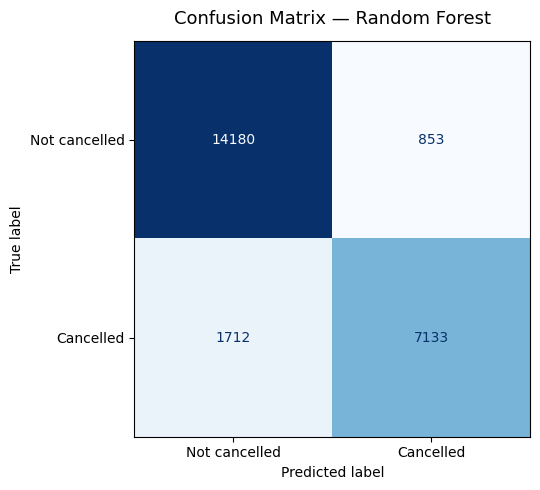

Saved → assets/confusion_matrix.png


In [2]:
# Cell 2 — Confusion matrix
#
# Rows = actual label. Columns = predicted label.
# Top-left:  True Negatives  (correctly predicted 'stayed')
# Top-right: False Positives (predicted 'cancelled' but they stayed)
# Bot-left:  False Negatives (predicted 'stayed' but they cancelled) ← the costly errors
# Bot-right: True Positives  (correctly predicted 'cancelled')

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not cancelled', 'Cancelled'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(ASSETS / 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved → assets/confusion_matrix.png')

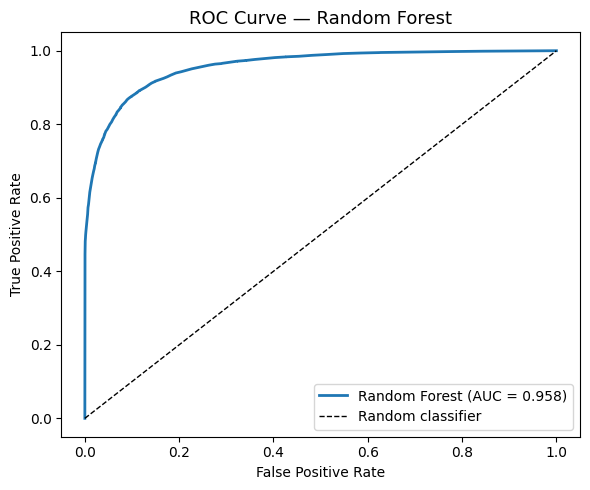

AUC = 0.958
Saved → assets/roc_curve.png


In [3]:
# Cell 3 — ROC curve + AUC
#
# ROC plots True Positive Rate vs False Positive Rate at every possible threshold.
# AUC (Area Under Curve): 0.5 = coin flip, 1.0 = perfect, >0.85 = strong model.
# The diagonal dashed line is a random classifier — we want to be far above it.

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Random Forest', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(ASSETS / 'roc_curve.png', dpi=150)
plt.show()
print(f'AUC = {auc:.3f}')
print('Saved → assets/roc_curve.png')

In [ ]:
# Cell 4 — SHAP feature importance
#
# SHAP (SHapley Additive exPlanations) answers: "why did the model predict this?"
# For each feature, SHAP assigns a value showing how much it pushed the prediction
# toward 'cancelled' (positive) or 'not cancelled' (negative).
# We use a small sample (500 rows) to keep runtime under a minute.

# Extract the fitted preprocessor and classifier from the pipeline
fitted_preprocessor = rf_pipeline.named_steps['preprocessor']
fitted_clf = rf_pipeline.named_steps['classifier']

# Transform the test set using only the preprocessor
X_test_transformed = fitted_preprocessor.transform(X_test)

# Get feature names after one-hot encoding
num_feature_names = numeric_cols
cat_feature_names = fitted_preprocessor.named_transformers_['cat']\
    .named_steps['encoder'].get_feature_names_out(categorical_cols).tolist()
feature_names = num_feature_names + cat_feature_names

# Sample 500 rows for SHAP (full test set takes too long for RF)
np.random.seed(42)
sample_idx = np.random.choice(X_test_transformed.shape[0], 500, replace=False)
X_sample = X_test_transformed[sample_idx]

print('Computing SHAP values... (30-60 seconds)')
explainer = shap.TreeExplainer(fitted_clf)
shap_values = explainer.shap_values(X_sample)

# shap_values is a list [class_0_values, class_1_values] for binary classification
# We want class 1 (Cancelled)
shap_cancelled = shap_values[1] if isinstance(shap_values, list) else shap_values

print('Done! Plotting...')
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_cancelled, X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance — Top 15 (Random Forest)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(ASSETS / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → assets/shap_summary.png')

Computing SHAP values... (30-60 seconds)
